# 전자상거래(Walmart) 상품 카테고리별 구매 트렌드 분석 보고서

In [1]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm
for i in fm.fontManager.ttflist:
    if i.name.find('Gulim') != -1:
        print(i.name)

Gulim
New Gulim


## 1. 변수 탐색

In [3]:
# 데이터 불러오기
import pandas as pd

df = pd.read_csv("c:/githome/hipython_rep/data/walmart.csv")

# 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


- 총 데이터 수는 550068개이고, 10개의 column이 있으며 결측값은 없다.
- column의 종류는 범주형 변수 5개와 수치형 변수 5개로 이루어져 있다. 

In [8]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

모든 column에 결측값은 다 0이다.

In [5]:
#데이터 샘플 보기
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [6]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [ ]:
#'User_ID'의 값 목록 보기
df['User_ID'].value_counts()

User_ID
1001680    1026
1004277     979
1001941     898
1001181     862
1000889     823
           ... 
1004991       7
1005391       7
1000094       7
1005608       7
1000708       6
Name: count, Length: 5891, dtype: int64

- User_ID의 목록을 보면 '1001680' 고객님의 구매 횟수가 1026번으로 가장 많다.
- 최소 구매 횟수 고객님의 구매 수가 6번으로 walmart에는 한 번만 구매하는 고객님은 없음을 알 수 있다.

In [11]:
df['User_ID'].value_counts().describe()

count    5891.000000
mean       93.374300
std       107.190049
min         6.000000
25%        26.000000
50%        54.000000
75%       117.000000
max      1026.000000
Name: count, dtype: float64

- 고객님들의 구매 횟수의 평균이 93.374이고 표준편차는 107.190이다
- 75%, 즉 구매 횟수가 117번 이상인 고객님부터는 VIP 고객님으로 간주할 수 있다.

In [12]:
df['Purchase'].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

- 구매 가격의 평균값은 9263달러, 최댓값은 23961달러, 최솟값은 12달러로 제품간 가격 편차는 큰 편이다.

## 2. 데이터 전처리

### 결측값은 없으므로 결측치 처리를 하지 않는 대신 이상치를 처리하도록 한다.
- 이상치(Outlier) 보기 (Occupation, Marital_Status, Product_Category)

In [13]:
#폰트 지정
from matplotlib import rcParams
rcParams['font.family'] = 'Gulim'
rcParams['axes.unicode_minus'] = False

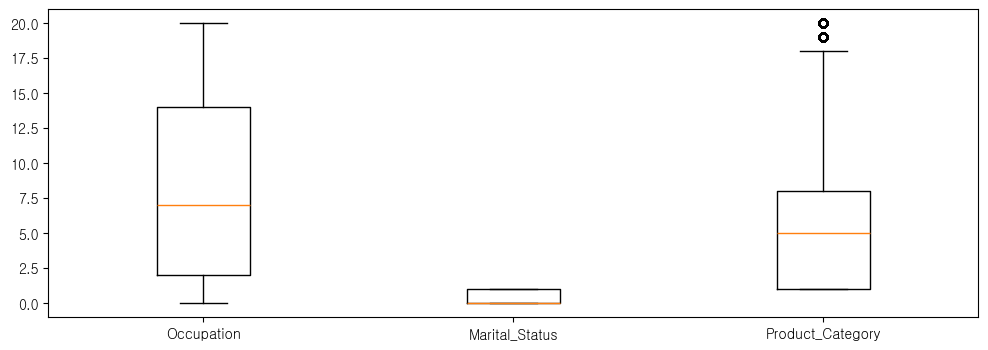

In [18]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,4))
axes = fig.add_subplot(1,1,1)

axes.boxplot(
             x=[
                 df['Occupation'],
                 df['Marital_Status'],
                 df['Product_Category'],
             ],
             labels=['Occupation', 'Marital_Status', 'Product_Category'])
plt.show()

'Product_Category' 에서 이상치가 발견되긴 하지만 크지도 많지도 않으므로 데이터 전처리 없이 원본 데이터프레임 그대로 분석을 진행하도록 한다.

In [19]:
df['Product_Category'].value_counts()

Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: count, dtype: int64

제품 카테고리에는 1번부터 20번까지 있고 5번 카테고리가 가장 많으며 9번 카테고리가 가장 적다.

## 3. 탐색적 데이터 분석 (EDA)
### 카테고리별 분포
- 상품 비중
- 총 금액
- 평균 금액
- 연령대별 구매 건수
- 거주 연차별 구매 건수
- 도시 유형별 구매 건수
- 결혼 여부별 구매 건수


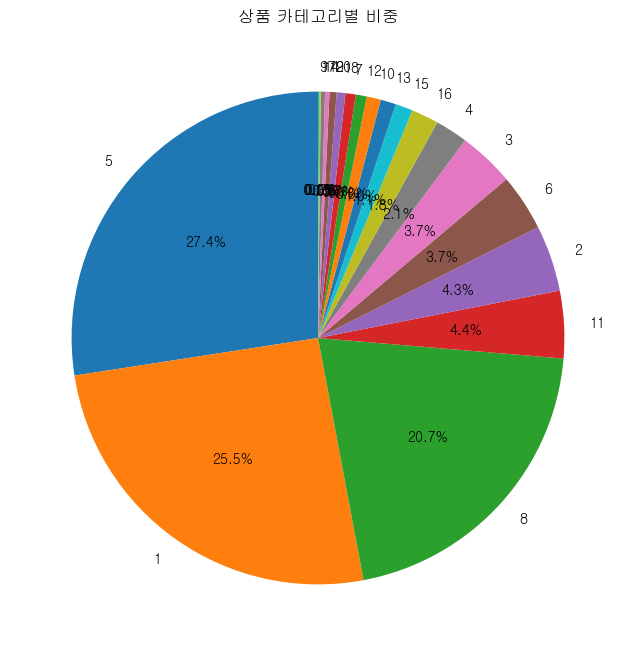

In [ ]:
#카테고리별로 비중 보기
category_counts = df['Product_Category'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts, labels=category_counts.index, autopct='%.1f%%', startangle=90)
plt.title('상품 카테고리별 비중')
plt.show()

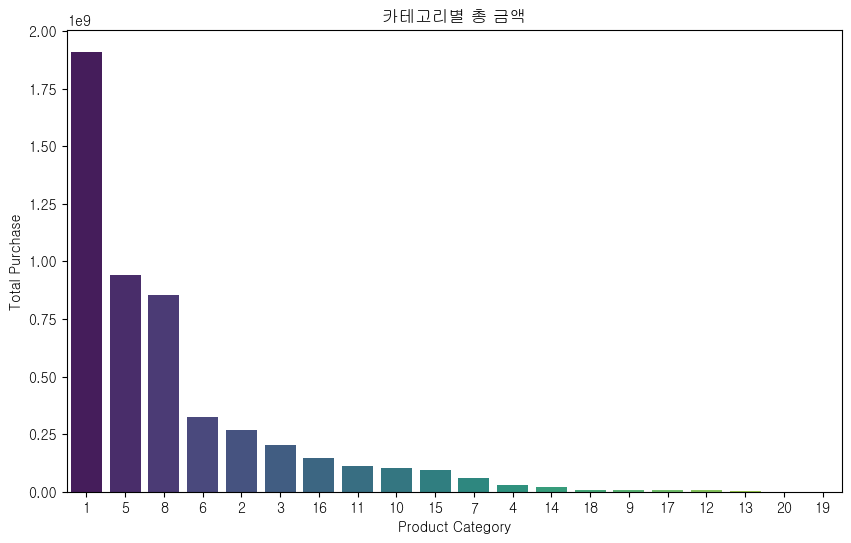

In [23]:
#각 카테고리에서 발생한 총 Purchase 금액 비교
import seaborn as sns

total_purchase_by_category = df.groupby('Product_Category')['Purchase'].sum().sort_values(ascending=False)   #내림차순 정렬
plt.figure(figsize=(10,6))
sns.barplot(x=total_purchase_by_category.index.astype(str), y=total_purchase_by_category.values, palette='viridis')
plt.title('카테고리별 총 금액')
plt.xlabel('Product Category')
plt.ylabel('Total Purchase')
plt.show()

- 파이차트와 비교했을 때, 5번 카테고리가 가장 많았고, 1번 카테고리가 그다음으로 많았지만 바차트에선 1번 카테고리 총 금액이 가장 많으며, 5번 카테고리가 그다음으로 많다.
- 1번 카테고리의 비율이 더 적지만, 평균 구매 금액이 높은 상품들일 가능성이 크다.  <br>

 => 따라서 "많이" 팔려면 5번 카테고리 제품군이 좋고, "비싸게" 팔려면 1번 카테고리 제품군이 좋다.

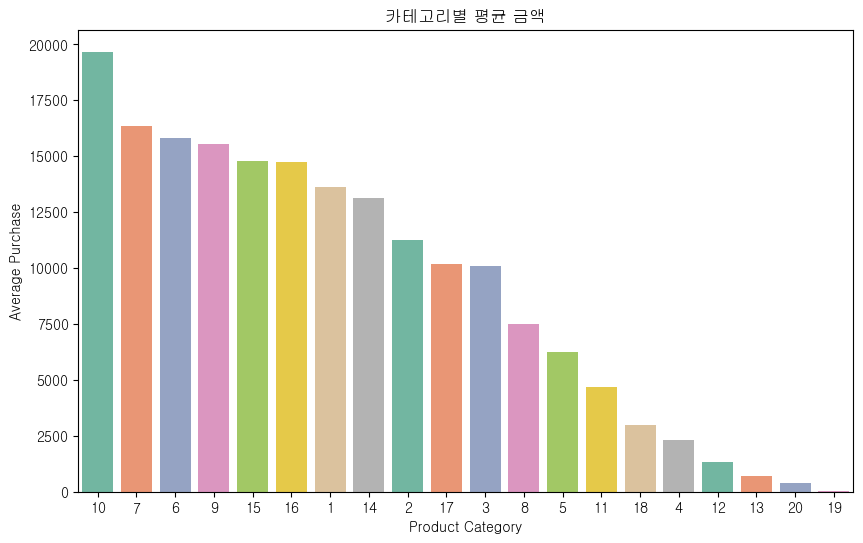

In [26]:
#카테고리별 평균 구매 금액
avg_purchase_by_category = df.groupby('Product_Category')['Purchase'].mean().sort_values(ascending=False)   #내림차순 정렬
plt.figure(figsize=(10,6))
sns.barplot(x=avg_purchase_by_category.index.astype(str), y=avg_purchase_by_category.values, palette='Set2')
plt.title('카테고리별 평균 금액')
plt.xlabel('Product Category')
plt.ylabel('Average Purchase')
plt.show()

- 총 금액과 비교했을 때 1번, 5번, 8번 순으로 높았는데 평균 금액은 10번, 7번, 6번 순으로 높다
- 큰 비율로 확 줄어들지 않고 비교적 안정된 하향 그래프가 그려진다.
- 총 금액과 비중에서는 5번 카테고리가 8번 카테고리보다 높지만, 평균 금액에서는 8번 카테고리가 5번 카테고리보다 높게 나타난다. 

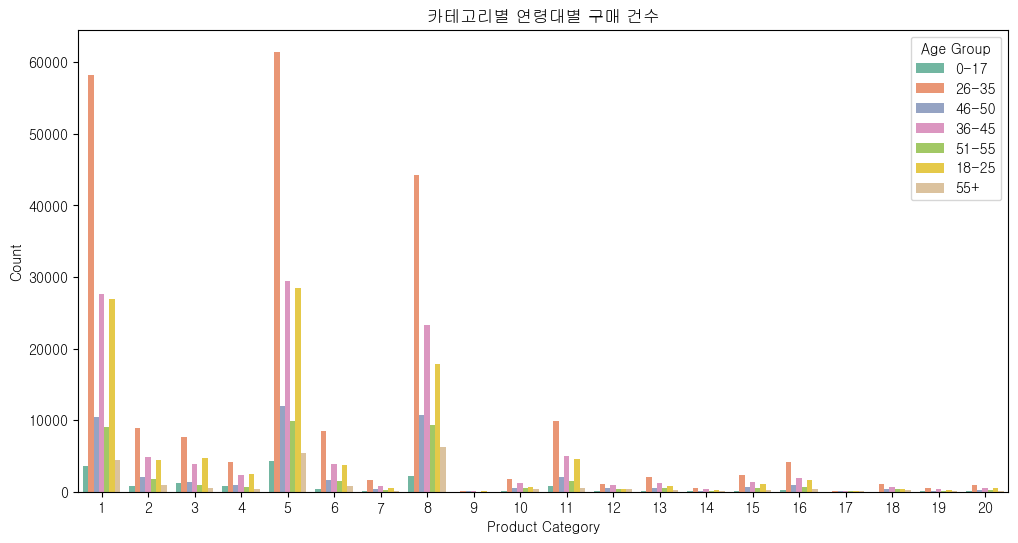

In [ ]:
#카테고리별 연령대별 구매 건수
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Product_Category', hue='Age', palette='Set2')
plt.title('카테고리별 연령대별 구매 건수')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.show()

- 전반적으로 26~35세 연령대가 거의 모든 카테고리에서 가장 많이 구매를 한다.
- 36~45세 연령대와 18~25세 연령대가 그다음으로 많이 구매를 한다. <br>

=> 따라서 26~35세 연령대 고객 대상으로 타겟팅을 설정하는 것이 좋다.

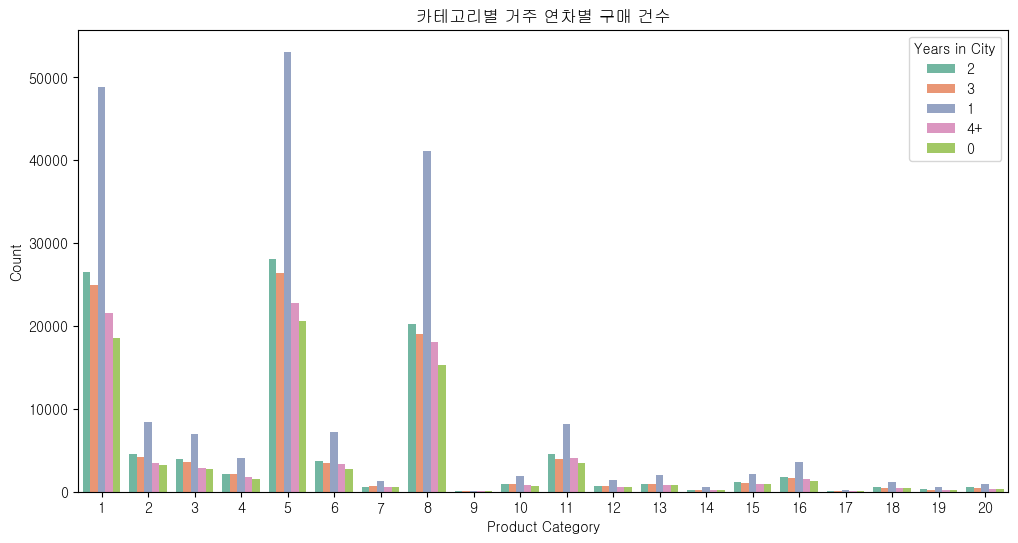

In [31]:
#카테고리별 거주 연차별 구매 건수
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Product_Category', hue='Stay_In_Current_City_Years', palette='Set2')
plt.title('카테고리별 거주 연차별 구매 건수')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.legend(title='Years in City')
plt.show()

- 전반적으로 거주한 지 1년차인 고객이 가장 많이 구매를 한다.
- 전반적으로 거주한 지 4년차 이상인 고객이 다른 연차에 비해 가장 적게 구매를 한다.
- 1년차를 제외하고는 큰 차이가 나지 않는다. <br>

=> 따라서 거주한 지 1년차 고객 대상으로 제품 타켓팅을 설정하는 것이 좋다.

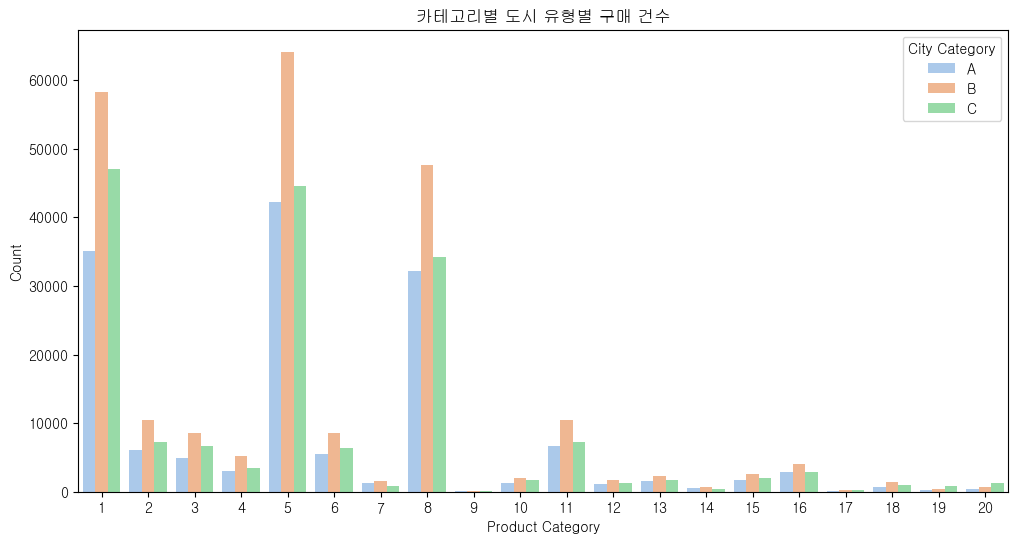

In [ ]:
#카테고리별 도시 유형별 구매 건수
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Product_Category', hue='City_Category', palette='pastel')
plt.title('카테고리별 도시 유형별 구매 건수')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.legend(title='City Category')
plt.show()

- 전반적으로 B지역 > C지역 > A지역 순으로 많이 구매를 한다. <br>

=> 따라서 B지역 고객들을 대상으로 제품 타겟팅을 하는 것이 좋다.

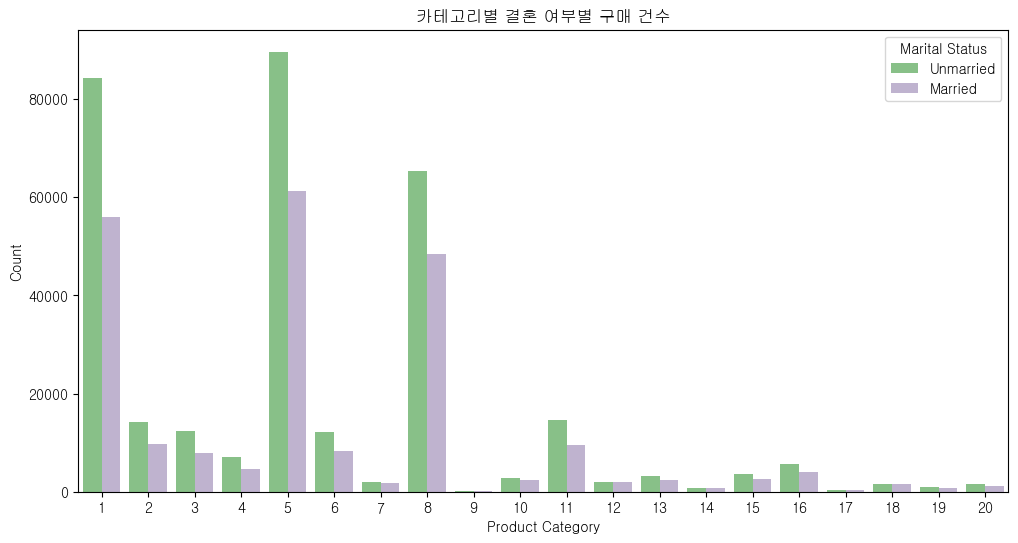

In [ ]:
#카테고리별 결혼 여부별 구매 건수
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Product_Category', hue='Marital_Status', palette='Accent')
plt.title('카테고리별 결혼 여부별 구매 건수')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.legend(title='Marital Status', labels=['Unmarried', 'Married'])
plt.show()

- 전반적으로 미혼 고객들이 기혼 고객들보다 더 많이 구매를 한다. <br>

=> 따라서 미혼 고객들을 대상으로 제품 타겟팅을 설정하는 것이 좋다.

## 4. 2차원 데이터 분석
###  상관계수 분석
- 구매 금액(Purchase)에 영향을 미치는 수치형 변수가 무엇인지 파악


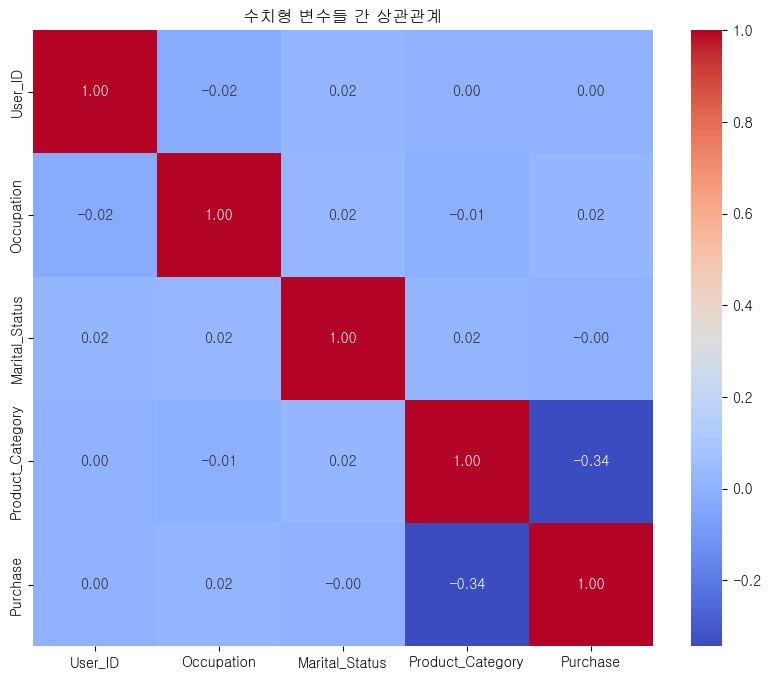

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 데이터 추출 후 상관계수 확인
df_corr = df.select_dtypes(include='number').corr()

# 히트맵으로 시각화
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('수치형 변수들 간 상관관계')
plt.show()

- Product_Category와 Purchase의 상관관계는 -0.34로 가장 낮게 나타난다.
- Purchase는 카테고리 외에 다른 변수들과는 0에 가까운 상관관계를 보인다. <br>

=> 카테고리 번호가 클수록 금액이 떨어진다고 해석 가능

## 5. 인사이트 도출
- 어떤 상품 카테고리의 비중이 가장 높은가?
> + 전체 판매 비중에서 **5번 카테고리**가 가장 높은 비율을 차지함. 
> + 해당 카테고리는 대중적이고 접근성이 높은 상품군일 가능성.
- 어떤 상품 카테고리에서 매출이 가장 높은가?
> + **1번 카테고리**가 가장 높은 총 금액을 기록.
> + 해당 카테고리는 고가 제품 비중이 높아, 비율은 가장 많지 않아도 총 구매 금액이 큼. 
- 어떤 상품 카테고리의 평균 구매 금액이 가장 높은가?
> + **10번 카테고리**의 평균 구매 금액이 가장 높음 -> **프리미엄 상품군**일 가능성 큼.
- 고객 연령대/거주 연차별/도시 유형별/결혼 여부 등에 따라 카테고리 선호가 달라지는가?
> + 45세 이하 연령대는 **5번 카테고리**를 가장 선호
> + 거주 1년차 고객들은 **5번 카테고리**를 가장 선호
> + 모든 도시 고객들은 **5번 카테고리**를 가장 선호 
> + 기혼자, 미혼자 모두 **5번 카테고리**를 가장 선호

## 6. 결론

**카테고리 5번은 가장 많은 구매 비중을 차지하며 대중적으로 널리 소비되는 품목**임을 나타냈고, <br> 반면 카테고리 **1번은 비교적 구매 빈도는 낮지만 총 매출이 높아 고가 상품군**으로 볼 수 있다.

이러한 결과는 고객의 선호도가 높고 자주 구매되는 상품과, 소수의 고객이 고가로 구매하는 상품을 구분하여 맞춤형 마케팅 전략을 수립할 필요성을 보여준다.

향후 분석에서는 고객 연령대, 성별, 지역 등과 상품 카테고리를 함께 고려하여 보다 정밀한 구매 패턴 파악이 이루어질 수 있을 것이다.